# Práctica de Redes Neuronales - Notebook 3

## Bootcamp Python - PY4
## Módulo 3: Deep Learning y NLP

En los dos notebooks anteriores construimos tres variantes de red neuronal
para el problema de Customer Churn:

- **Modelo A - El Minimalista**: una sola capa oculta pequeña.
- **Modelo B - El Profundo**: varias capas ocultas, mucha más capacidad.
- **Modelo C - El Optimizado**: la misma profundidad que B, pero con
  Dropout, regularización L2 y EarlyStopping.

Hoy hacemos la **mesa de auditoría**: en vez de mirar cada modelo por
separado, los vamos a poner lado a lado para comparar cómo se comportan, y
vamos a identificar visualmente el punto exacto de overfitting en cada uno.

Además, vamos a hacer dos experimentos puntuales para profundizar dos temas
que mencionamos pero no aislamos todavía:

1. **El impacto de la función de activación**: qué pasa si usamos `sigmoid`
   en vez de `relu` en una red profunda.
2. **El impacto de EarlyStopping por sí solo**: qué pasa si lo agregamos al
   Modelo B, sin Dropout ni regularización, para ver qué parte de la mejora
   del Modelo C viene solo de detener el entrenamiento a tiempo.



## 0. Repaso rápido: datos y los tres modelos

Repetimos, de forma condensada, la preparación de datos y el entrenamiento de
los tres modelos tal como quedaron en los notebooks anteriores. Ya
explicamos cada uno de estos pasos en detalle, así que hoy los ejecutamos
directamente para tener todo listo y empezar con la auditoría.


In [2]:
# Importamos las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)


In [3]:
# Cargamos y preparamos el dataset de Customer Churn, igual que siempre
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

data = df.copy()
data = data.drop(columns=["customerID"])
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data = data.dropna(subset=["TotalCharges"])

data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})
X = data.drop(columns=["Churn"])
y = data["Churn"]
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]
print("Features de entrada:", n_features)


Features de entrada: 30


In [4]:
# Reconstruimos y entrenamos el Modelo A
modelo_a = Sequential([
    Dense(8, activation="relu", input_shape=(n_features,)),
    Dense(1, activation="sigmoid")
])
modelo_a.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history_a = modelo_a.fit(
    X_train_scaled, y_train,
    epochs=50, batch_size=32, validation_split=0.2, verbose=0
)

# Reconstruimos y entrenamos el Modelo B
modelo_b = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])
modelo_b.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history_b = modelo_b.fit(
    X_train_scaled, y_train,
    epochs=50, batch_size=32, validation_split=0.2, verbose=0
)

# Reconstruimos y entrenamos el Modelo C
modelo_c = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,),
          kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(16, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])
modelo_c.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
history_c = modelo_c.fit(
    X_train_scaled, y_train,
    epochs=100, batch_size=32, validation_split=0.2,
    callbacks=[early_stopping], verbose=0
)

print("Modelo A entrenado:", len(history_a.history["loss"]), "epochs")
print("Modelo B entrenado:", len(history_b.history["loss"]), "epochs")
print("Modelo C entrenado:", len(history_c.history["loss"]), "epochs")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Modelo A entrenado: 50 epochs
Modelo B entrenado: 50 epochs
Modelo C entrenado: 43 epochs


## 1. Mesa de auditoría: comparando las curvas de los tres modelos

Ahora sí, el corazón de esta sesión: vamos a graficar el `val_loss` y el
`val_accuracy` de los tres modelos juntos, en un mismo gráfico, para poder
compararlos directamente.

Recordá que el `val_loss` (loss sobre el conjunto de validación) es el
indicador más importante para detectar overfitting: mientras el loss de
entrenamiento casi siempre sigue bajando, el de validación es el que nos
avisa cuándo el modelo empieza a memorizar en vez de generalizar.


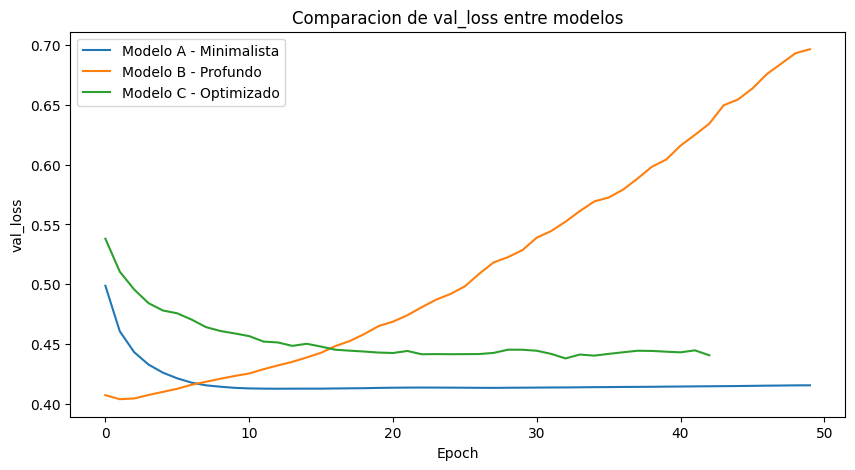

In [5]:
# Comparamos el val_loss de los tres modelos en un mismo grafico
plt.figure(figsize=(10, 5))
plt.plot(history_a.history["val_loss"], label="Modelo A - Minimalista")
plt.plot(history_b.history["val_loss"], label="Modelo B - Profundo")
plt.plot(history_c.history["val_loss"], label="Modelo C - Optimizado")
plt.title("Comparacion de val_loss entre modelos")
plt.xlabel("Epoch")
plt.ylabel("val_loss")
plt.legend()
plt.show()


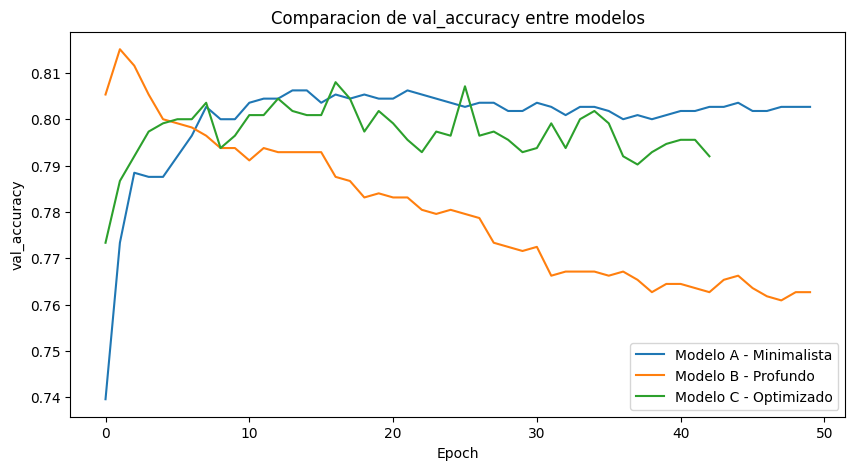

In [6]:
# Comparamos el val_accuracy de los tres modelos en un mismo grafico
plt.figure(figsize=(10, 5))
plt.plot(history_a.history["val_accuracy"], label="Modelo A - Minimalista")
plt.plot(history_b.history["val_accuracy"], label="Modelo B - Profundo")
plt.plot(history_c.history["val_accuracy"], label="Modelo C - Optimizado")
plt.title("Comparacion de val_accuracy entre modelos")
plt.xlabel("Epoch")
plt.ylabel("val_accuracy")
plt.legend()
plt.show()


### Para discutir en la mesa de auditoría

Mirando los dos gráficos anteriores:

- ¿Cuál modelo tiene el `val_loss` más bajo en algún punto del entrenamiento?
  ¿Es el mismo modelo que termina con el `val_loss` más bajo al final?
- ¿El Modelo B muestra una curva de `val_loss` que en algún momento deja de
  bajar o empieza a subir, mientras los otros dos siguen relativamente
  estables?
- ¿El Modelo C logra un `val_loss` parecido al del Modelo A, a pesar de tener
  muchos más parámetros (la misma cantidad que el Modelo B)?


 **¿Cuál modelo tiene el `val_loss` más bajo en algún punto del entrenamiento? ¿Es el mismo modelo que termina con el `val_loss` más bajo al final?**

Sí. El **Modelo A** alcanza el `val_loss` más bajo durante el entrenamiento y también es el modelo que termina con el **menor `val_loss`** al final de las épocas.

El Modelo C consigue un `val_loss` relativamente bajo, pero nunca llega a superar al Modelo A. El Modelo B, en cambio, termina con un `val_loss` mucho mayor debido al sobreajuste.

---

 **¿El Modelo B muestra una curva de `val_loss` que en algún momento deja de bajar o empieza a subir, mientras los otros dos siguen relativamente estables?**

Sí. Después de las primeras épocas, el **Modelo B** deja de mejorar y su `val_loss` comienza a aumentar de forma continua. Esto es una señal clara de **overfitting**: el modelo sigue aprendiendo el conjunto de entrenamiento, pero cada vez generaliza peor sobre datos nuevos.

En comparación:

- El **Modelo A** mantiene un `val_loss` prácticamente constante una vez que converge.
- El **Modelo C** también estabiliza su `val_loss`, con un ligero aumento al final, pero mucho más moderado que el observado en el Modelo B.

---

 **¿El Modelo C logra un `val_loss` parecido al del Modelo A, a pesar de tener muchos más parámetros (la misma cantidad que el Modelo B)?**

Sí. Aunque el **Modelo C** tiene la misma arquitectura y el mismo número de parámetros que el Modelo B, consigue un `val_loss` mucho más cercano al del Modelo A.

Esto demuestra que las técnicas de **regularización** (Dropout, L2 y EarlyStopping) ayudan a controlar el sobreajuste. En otras palabras, el Modelo C conserva la capacidad de una red profunda, pero consigue un comportamiento mucho más parecido al de un modelo que generaliza correctamente.

## 2. Identificando el punto exacto de overfitting

En vez de solo mirar el gráfico "a ojo", vamos a identificar
programáticamente, para cada modelo, en qué epoch se logró el `val_loss` más
bajo. A partir de ese punto, si el `loss` de entrenamiento sigue bajando pero
el `val_loss` ya no mejora, eso marca el inicio del overfitting.

Usamos `np.argmin(...)` sobre el historial de `val_loss` para encontrar ese
epoch.


In [7]:
# Funcion para encontrar el epoch con el mejor (mas bajo) val_loss
def epoch_mejor_val_loss(history):
    val_loss = history.history["val_loss"] # Extraemos la lista con los valores de val_loss registrados en cada epoch

    mejor_epoch = int(np.argmin(val_loss)) # Buscamos el índice (epoch) donde el val_loss fue mínimo (argmin return el índice donde se encuentra el valor más pequeño)

    return mejor_epoch, val_loss[mejor_epoch] # Devolvemos el número de la mejor epoch y el valor mínimo de val_loss


# Calculamos el punto de mejor val_loss para cada modelo
epoch_a, valloss_a = epoch_mejor_val_loss(history_a)
epoch_b, valloss_b = epoch_mejor_val_loss(history_b)
epoch_c, valloss_c = epoch_mejor_val_loss(history_c)

print(f"Modelo A: mejor val_loss en el epoch {epoch_a + 1} (val_loss = {valloss_a:.4f}), de {len(history_a.history['loss'])} epochs totales")
print(f"Modelo B: mejor val_loss en el epoch {epoch_b + 1} (val_loss = {valloss_b:.4f}), de {len(history_b.history['loss'])} epochs totales")
print(f"Modelo C: mejor val_loss en el epoch {epoch_c + 1} (val_loss = {valloss_c:.4f}), de {len(history_c.history['loss'])} epochs totales")


Modelo A: mejor val_loss en el epoch 13 (val_loss = 0.4126), de 50 epochs totales
Modelo B: mejor val_loss en el epoch 2 (val_loss = 0.4038), de 50 epochs totales
Modelo C: mejor val_loss en el epoch 33 (val_loss = 0.4379), de 43 epochs totales


Si el "mejor epoch" de un modelo está muy lejos del último epoch
entrenado, eso significa que seguimos entrenando muchos epochs de más,
después de que el modelo ya había alcanzado su mejor punto de generalización.
Ese tramo extra de entrenamiento es, en la práctica, tiempo que el modelo usó
para sobreajustarse en vez de mejorar.

Vamos a graficar de nuevo el `val_loss` del Modelo B, marcando con una línea
vertical el epoch de su mejor punto, para visualizarlo claramente.


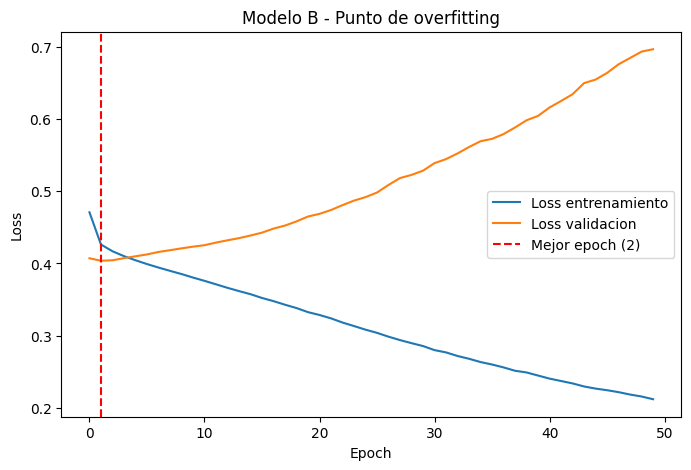

In [8]:
# Graficamos el val_loss del Modelo B, marcando el punto de mejor val_loss
plt.figure(figsize=(8, 5))
plt.plot(history_b.history["loss"], label="Loss entrenamiento")
plt.plot(history_b.history["val_loss"], label="Loss validacion")
plt.axvline(epoch_b, color="red", linestyle="--", label=f"Mejor epoch ({epoch_b + 1})")
plt.title("Modelo B - Punto de overfitting")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


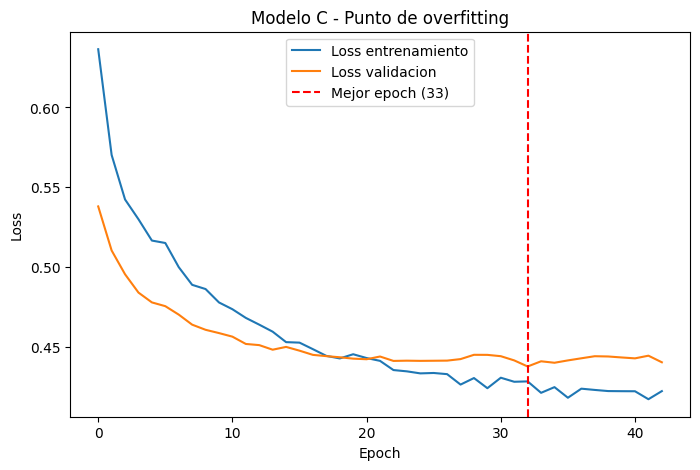

In [9]:
# Graficamos el val_loss del Modelo C, marcando el punto de mejor val_loss
plt.figure(figsize=(8, 5))
plt.plot(history_c.history["loss"], label="Loss entrenamiento")
plt.plot(history_c.history["val_loss"], label="Loss validacion")
plt.axvline(epoch_c, color="red", linestyle="--", label=f"Mejor epoch ({epoch_c + 1})")
plt.title("Modelo C - Punto de overfitting")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


## 3. Experimento: el impacto de la función de activación

La funcion de activacion `relu` es "el estándar de oro" para las capas
ocultas, principalmente porque evita el **desvanecimiento del gradiente**
(vanishing gradient): cuando se usan funciones como `sigmoid` en varias capas
seguidas, los gradientes que se propagan hacia atrás durante el entrenamiento
se van achicando cada vez más, y las primeras capas de la red terminan
aprendiendo muy lento (o casi nada).

Para verlo en la práctica, vamos a tomar la arquitectura del Modelo B (la
profunda, con 3 capas ocultas) y entrenar dos versiones:

- **Modelo B - ReLU**: el mismo Modelo B que ya entrenamos.
- **Modelo B - Sigmoid**: exactamente la misma arquitectura, pero
  reemplazando `relu` por `sigmoid` en las capas ocultas.

Todo lo demás (cantidad de capas, cantidad de neuronas, optimizer, loss,
epochs) queda igual, para que la única diferencia sea la función de
activación.


In [10]:
# Construimos la version del Modelo B con activacion sigmoid en las capas ocultas
modelo_b_sigmoid = Sequential([
    Dense(64, activation="sigmoid", input_shape=(n_features,)),
    Dense(32, activation="sigmoid"),
    Dense(16, activation="sigmoid"),
    Dense(1, activation="sigmoid")
])

modelo_b_sigmoid.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_b_sigmoid = modelo_b_sigmoid.fit(
    X_train_scaled, y_train,
    epochs=50, batch_size=32, validation_split=0.2, verbose=0
)

print("Entrenamiento completado")


Entrenamiento completado


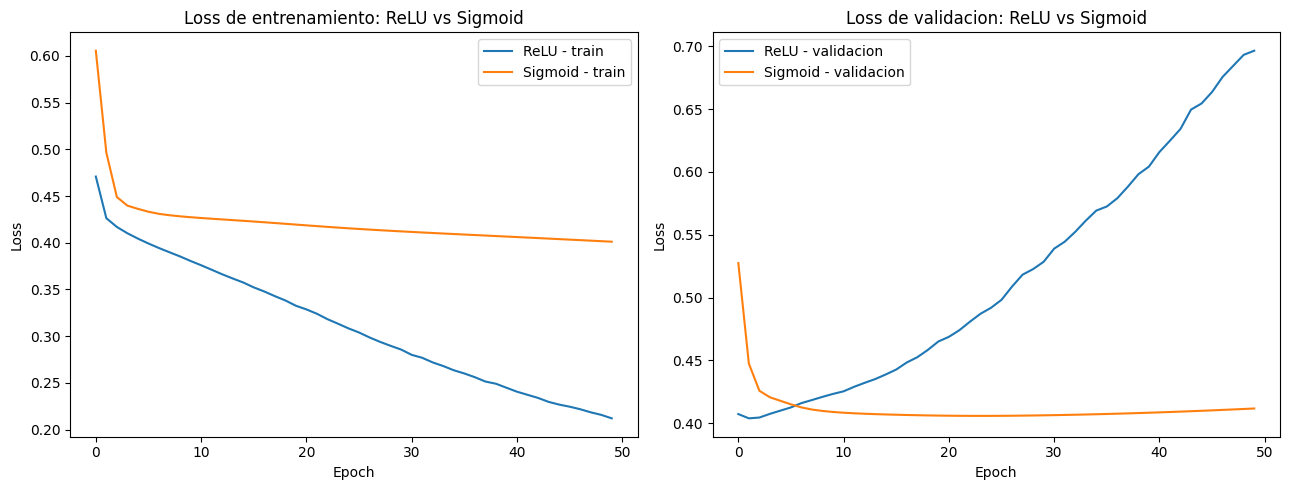

Modelo B - ReLU:    test_loss = 0.6834, test_accuracy = 0.7626
Modelo B - Sigmoid: test_loss = 0.4328, test_accuracy = 0.7861


In [11]:
# Comparamos las curvas de loss: relu vs sigmoid, en la misma arquitectura profunda
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_b.history["loss"], label="ReLU - train")
axes[0].plot(history_b_sigmoid.history["loss"], label="Sigmoid - train")
axes[0].set_title("Loss de entrenamiento: ReLU vs Sigmoid")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_b.history["val_loss"], label="ReLU - validacion")
axes[1].plot(history_b_sigmoid.history["val_loss"], label="Sigmoid - validacion")
axes[1].set_title("Loss de validacion: ReLU vs Sigmoid")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# Comparamos tambien el resultado final sobre el conjunto de test
loss_relu, acc_relu = modelo_b.evaluate(X_test_scaled, y_test, verbose=0)
loss_sigmoid, acc_sigmoid = modelo_b_sigmoid.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Modelo B - ReLU:    test_loss = {loss_relu:.4f}, test_accuracy = {acc_relu:.4f}")
print(f"Modelo B - Sigmoid: test_loss = {loss_sigmoid:.4f}, test_accuracy = {acc_sigmoid:.4f}")


### Para discutir

Este experimento suele mostrar dos efectos distintos, uno encima del otro, y
vale la pena separarlos con cuidado:

- **En el loss de entrenamiento** (gráfico de la izquierda): con `relu`, el
  loss baja rápido y sigue bajando bastante. Con `sigmoid`, el loss baja
  mucho más lento y se queda "atascado" en un valor más alto. Esto es la
  firma directa del **desvanecimiento del gradiente**: con varias capas
  `sigmoid` seguidas, el gradiente que llega a las primeras capas se va
  achicando, y la red aprende mucho más lento.

- **En el loss de validación** (gráfico de la derecha), puede pasar algo que
  a primera vista parece contradictorio: como la versión con `relu` aprende
  rápido y esta arquitectura no tiene ningún tipo de regularización (es el
  Modelo B tal cual), esa velocidad de aprendizaje también la lleva a
  sobreajustarse antes. La versión con `sigmoid`, al aprender tan lento,
  ni siquiera llega a memorizar el set de entrenamiento en 50 epochs, así
  que su `val_loss` puede verse más estable, o incluso "mejor" en el corto
  plazo.

Es importante no leer esto como "entonces sigmoid es mejor". Lo que está
pasando es que la versión con `sigmoid` está **subentrenada** (underfitting):
casi no logra reducir su loss de entrenamiento, no porque haya encontrado un
mejor punto, sino porque el desvanecimiento del gradiente le impide seguir
aprendiendo. `relu` sigue siendo la elección correcta para las capas
ocultas; lo que este experimento nos muestra es que una convergencia rápida
(su principal ventaja) tiene que ir acompañada de herramientas de
regularización (como las del Modelo C) para no terminar sobreajustando.

Preguntas para la mesa de auditoría:

- ¿Cuál de los dos loss de entrenamiento baja más rápido en los primeros 10
  epochs?
- ¿Por qué la curva de validación de `sigmoid` puede verse "tranquila" sin
  que eso signifique que el modelo esté aprendiendo bien?
- Si combináramos `sigmoid` con Dropout y regularización, como en el Modelo
  C, ¿esperarían que mejore mucho, o el problema de fondo (el
  desvanecimiento del gradiente) seguiría limitando el aprendizaje?


## 4. Experimento: aislando el efecto de EarlyStopping

El Modelo C combina tres técnicas al mismo tiempo: Dropout, regularización L2
y EarlyStopping. Eso es excelente para obtener el mejor resultado posible,
pero nos deja una pregunta abierta: ¿cuánto de la mejora viene solamente de
`EarlyStopping`, sin Dropout ni regularización?

Vamos a entrenar una nueva variante, **Modelo B + EarlyStopping**: la misma
arquitectura profunda del Modelo B (sin Dropout, sin regularización L2), pero
agregándole únicamente el callback de `EarlyStopping`.


In [12]:
# Construimos la misma arquitectura que el Modelo B, sin Dropout ni regularizacion
modelo_b_earlystop = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

modelo_b_earlystop.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Le agregamos unicamente el callback de EarlyStopping
early_stopping_b = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history_b_earlystop = modelo_b_earlystop.fit(
    X_train_scaled, y_train,
    epochs=100, batch_size=32, validation_split=0.2,
    callbacks=[early_stopping_b], verbose=0
)

print("Epochs efectivamente entrenados:", len(history_b_earlystop.history["loss"]))


Epochs efectivamente entrenados: 12


In [13]:
# Evaluamos esta nueva variante sobre el conjunto de test
loss_b_es, acc_b_es = modelo_b_earlystop.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Modelo B (sin nada):          test_loss = {loss_relu:.4f}, test_accuracy = {acc_relu:.4f}")
print(f"Modelo B + EarlyStopping:     test_loss = {loss_b_es:.4f}, test_accuracy = {acc_b_es:.4f}")

loss_c, acc_c = modelo_c.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Modelo C (Dropout+L2+ES):     test_loss = {loss_c:.4f}, test_accuracy = {acc_c:.4f}")


Modelo B (sin nada):          test_loss = 0.6834, test_accuracy = 0.7626
Modelo B + EarlyStopping:     test_loss = 0.4292, test_accuracy = 0.7953
Modelo C (Dropout+L2+ES):     test_loss = 0.4541, test_accuracy = 0.7839


### Para discutir

- ¿`EarlyStopping` por sí solo ya mejora el resultado del Modelo B, o hace
  falta combinarlo con Dropout y regularización para ver una mejora real?
- ¿En cuántos epochs se detuvo el Modelo B + EarlyStopping, comparado con los
  epochs del Modelo C?
- Pensando en las tres versiones del Modelo B que entrenamos hoy (sin nada,
  con EarlyStopping solo, y el Modelo C completo), ¿qué técnica creen que
  aporta más a la generalización en este problema en particular?


## 5. Tabla resumen final

Armamos una tabla con todos los modelos que entrenamos hoy y en los notebooks
anteriores, para tener una vista completa de la mesa de auditoría.


In [14]:
# Armamos la tabla resumen con todos los modelos
resumen = pd.DataFrame({
    "Modelo": [
        "A - Minimalista",
        "B - Profundo",
        "C - Optimizado (Dropout+L2+ES)",
        "B - Sigmoid (en vez de ReLU)",
        "B + EarlyStopping (solo)",
    ],
    "Test Loss": [
        modelo_a.evaluate(X_test_scaled, y_test, verbose=0)[0],
        loss_relu,
        loss_c,
        loss_sigmoid,
        loss_b_es,
    ],
    "Test Accuracy": [
        modelo_a.evaluate(X_test_scaled, y_test, verbose=0)[1],
        acc_relu,
        acc_c,
        acc_sigmoid,
        acc_b_es,
    ],
    "Epochs entrenados": [
        len(history_a.history["loss"]),
        len(history_b.history["loss"]),
        len(history_c.history["loss"]),
        len(history_b_sigmoid.history["loss"]),
        len(history_b_earlystop.history["loss"]),
    ],
})

resumen


,Modelo,Test Loss,Test Accuracy,Epochs entrenados
0,A - Minimalista,0.432472,0.792466,50
1,B - Profundo,0.683358,0.762616,50
2,C - Optimizado (Dropout+L2+ES),0.454055,0.783937,43
3,B - Sigmoid (en vez de ReLU),0.432845,0.786070,50
4,B + EarlyStopping (solo),0.429222,0.795309,12


## Cierre del módulo

A lo largo de estas tres sesiones:

- Entendimos, con numpy, qué hace matemáticamente una neurona y una capa, y
  tuvimos una primera intuición de cómo se ajustan los pesos durante el
  entrenamiento.
- Construimos y comparamos tres arquitecturas distintas (Modelo A, B y C)
  para el mismo problema de negocio: predecir la fuga de clientes.
- Aprendimos a leer curvas de loss y accuracy para detectar overfitting, y a
  identificar programáticamente el punto exacto donde empieza.
- Aislamos el efecto de la función de activación y del uso de
  `EarlyStopping`, para entender qué aporta cada técnica por separado.

La conclusión más importante de esta mesa de auditoría es que **más
capacidad no es sinónimo de mejor modelo**: el Modelo B, con miles de
parámetros más que el Modelo A, no necesariamente lo superó. Lo que marca la
diferencia es usar esa capacidad de forma cuidada, con las herramientas
correctas para favorecer la generalización.
